In [23]:
import os
import pandas as pd
from data.metrics import Evaluator
from data.small_context import get_datasets
from sklearn.metrics import mean_absolute_error
from loguru import logger
import numpy as np
from matplotlib import pyplot as plt
import torch
from models.chronos_forecast import get_predictions_chronos
plt.style.use('tableau-colorblind10')

output_path = './outputs/darts/with_fewshot_chronos/'
filelist = os.listdir(output_path)
filelist

['WoolyDataset.pkl',
 'AusBeerDataset.pkl',
 'AirPassengersDataset.pkl',
 'WineDataset.pkl',
 'HeartRateDataset.pkl',
 'GasRateCO2Dataset.pkl',
 'MonthlyMilkDataset.pkl',
 'SunspotsDataset.pkl']

# Darts

In [25]:
computed_datasets = list(get_datasets().keys())
computed_datasets = [d for d in computed_datasets if d+".pkl" in filelist]
computed_datasets

['AirPassengersDataset',
 'AusBeerDataset',
 'GasRateCO2Dataset',
 'MonthlyMilkDataset',
 'SunspotsDataset',
 'WineDataset',
 'WoolyDataset',
 'HeartRateDataset']

In [26]:
chronos_out = {}
for dsname,data in get_datasets().items():
    if dsname not in computed_datasets:
        continue
    train, test = data

    quantiles, median = get_predictions_chronos(
        input_tensor=torch.tensor(train.values),
        prediction_length=len(test),
        quantiles=[0.1, 0.5, 0.9]
    )
    chronos_out[dsname] = {'median': pd.Series(median.cpu().numpy().squeeze(), index=test.index, name="Y")}

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/chronos/chronos_bolt.py:525: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


In [27]:
chronos_out['AirPassengersDataset']['median']

Month
1958-08-01    477.269867
1958-09-01    430.373901
1958-10-01    358.608856
1958-11-01    342.976868
1958-12-01    363.582672
1959-01-01    374.951385
1959-02-01    388.451721
1959-03-01    411.899719
1959-04-01    419.715698
1959-05-01    428.952820
1959-06-01    471.585510
1959-07-01    515.639282
1959-08-01    512.797119
1959-09-01    474.427673
1959-10-01    404.794250
1959-11-01    382.767395
1959-12-01    394.136108
1960-01-01    405.504822
1960-02-01    419.005188
1960-03-01    433.216064
1960-04-01    436.058258
1960-05-01    443.163696
1960-06-01    497.165100
1960-07-01    542.640015
1960-08-01    535.534546
1960-09-01    494.322937
1960-10-01    426.110626
1960-11-01    409.768066
1960-12-01    427.531708
Freq: MS, Name: Y, dtype: float32

In [33]:
temp = pd.read_pickle(f'{output_path}/{computed_datasets[0]}.pkl')
temp.keys()

dict_keys(['gpt-4', 'gemma-12b', 'qwen-30b'])

In [34]:
score_rag = []
score_norag = []
score_chronos = []

for dataset_name in computed_datasets:
    output_rag = pd.read_pickle(f'{output_path}/{dataset_name}.pkl')
    gt = get_datasets()[dataset_name]
    for model in output_rag.keys():
        logger.info(f"RAG for {dataset_name} - {model}")
        mae_rag = mean_absolute_error(gt[1], output_rag[model]['median'])
        score_rag.append((model+" (RAG)", dataset_name, mae_rag))

    mae_chronos = mean_absolute_error(gt[1], chronos_out[dataset_name]['median'])
    score_chronos.append(("chronos", dataset_name, mae_chronos))

    output_norag = pd.read_pickle(f'./precomputed_outputs/darts/gpt4/{dataset_name}.pkl')
    mae_norag = mean_absolute_error(gt[1], output_norag['gpt-4']['median'])
    score_norag.append(('gpt-4', dataset_name, mae_norag))
        


2025-10-02 09:57:08.796 | INFO     | __main__:<module>:9 - RAG for AirPassengersDataset - gpt-4
2025-10-02 09:57:08.798 | INFO     | __main__:<module>:9 - RAG for AirPassengersDataset - gemma-12b
2025-10-02 09:57:08.799 | INFO     | __main__:<module>:9 - RAG for AirPassengersDataset - qwen-30b
2025-10-02 09:57:08.829 | INFO     | __main__:<module>:9 - RAG for AusBeerDataset - gpt-4
2025-10-02 09:57:08.830 | INFO     | __main__:<module>:9 - RAG for AusBeerDataset - gemma-12b
2025-10-02 09:57:08.832 | INFO     | __main__:<module>:9 - RAG for AusBeerDataset - qwen-30b
2025-10-02 09:57:08.868 | INFO     | __main__:<module>:9 - RAG for GasRateCO2Dataset - gpt-4
2025-10-02 09:57:08.870 | INFO     | __main__:<module>:9 - RAG for GasRateCO2Dataset - gemma-12b
2025-10-02 09:57:08.872 | INFO     | __main__:<module>:9 - RAG for GasRateCO2Dataset - qwen-30b
2025-10-02 09:57:08.902 | INFO     | __main__:<module>:9 - RAG for MonthlyMilkDataset - gpt-4
2025-10-02 09:57:08.904 | INFO     | __main__:<m

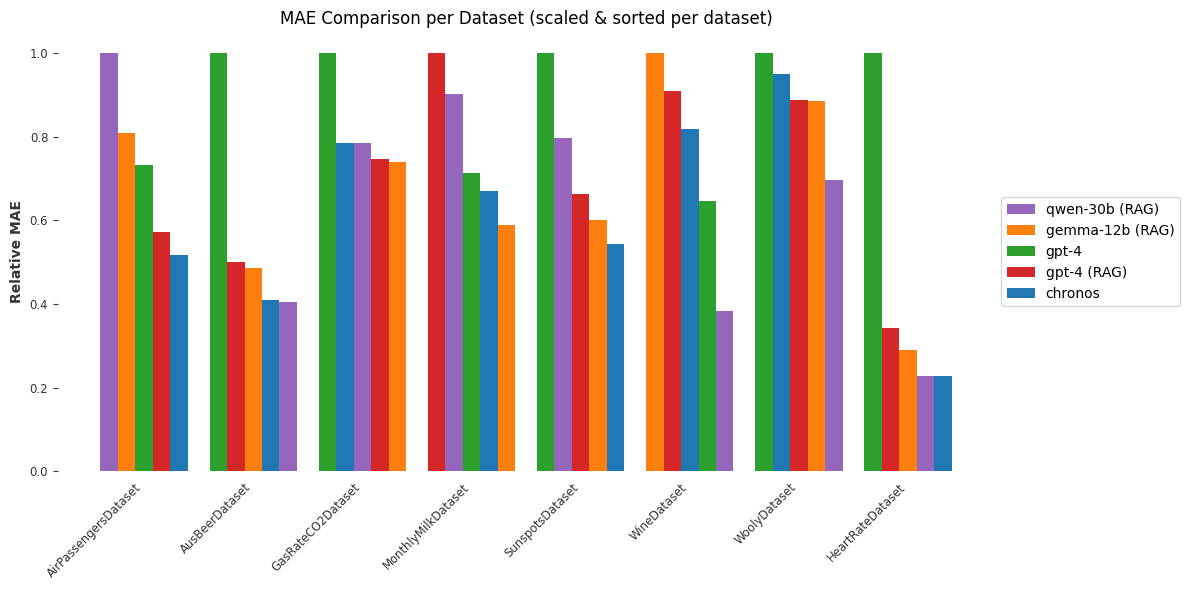

In [43]:
df_scores = pd.DataFrame(score_rag + score_norag + score_chronos, columns=["model", "dataset", "mae"])
df_scores = df_scores.groupby(["model", "dataset"], as_index=False)["mae"].mean()

df_pivot = df_scores.pivot(index="model", columns="dataset", values="mae")
df_pivot = df_pivot.reindex(columns=[ds for ds in computed_datasets if ds in df_pivot.columns])
model_names = df_pivot.index.tolist()
datasets = df_pivot.columns.tolist()

values = df_pivot.to_numpy(dtype=float)
max_per_dataset = np.nanmax(values, axis=0)
max_per_dataset = np.where((max_per_dataset == 0) | np.isnan(max_per_dataset), 1, max_per_dataset)
scaled_values = np.nan_to_num(values / max_per_dataset)

cmap = plt.get_cmap("tab10")
colors = {model: cmap(i % cmap.N) for i, model in enumerate(model_names)}

x = np.arange(len(datasets))
width = 0.8
bar_width = width / max(len(model_names), 1)

fig, ax = plt.subplots(figsize=(12, 6))
seen_labels = set()

for j, ds in enumerate(datasets):
    vals = scaled_values[:, j]
    order = np.argsort(-vals)
    for position, idx in enumerate(order):
        if np.isnan(values[idx, j]):
            continue
        model = model_names[idx]
        label = model if model not in seen_labels else ""
        ax.bar(
            j - width / 2 + (position + 0.5) * bar_width,
            vals[idx],
            bar_width,
            color=colors[model],
            label=label
        )
        seen_labels.add(model)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha="right")
ax.set_ylabel("Relative MAE")
ax.set_title("MAE Comparison per Dataset (scaled & sorted per dataset)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()

In [18]:
logger.info(f"RAG MAE: {score_rag}")
logger.info(f"GPT-4 MAE: {score_norag}")
logger.info(f"Chronos MAE: {score_chronos}")

2025-10-01 16:04:54.351 | INFO     | __main__:<module>:1 - RAG MAE: [('AirPassengersDataset', 39.07340689655173), ('AusBeerDataset', 11.991172093023236)]
2025-10-01 16:04:54.354 | INFO     | __main__:<module>:2 - GPT-4 MAE: [('AirPassengersDataset', 34.549255172413815), ('AusBeerDataset', 27.68199999999997)]
2025-10-01 16:04:54.357 | INFO     | __main__:<module>:3 - Chronos MAE: [('AirPassengersDataset', 24.352636929216057), ('AusBeerDataset', 11.324950462163882)]
